# INITIALIZATION

In [323]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from config import BCI2A_PATH, MI_DATA_PATH, LOW_FREQ, HIGH_FREQ, SAMPLING_RATE, BCI_MAPPING
# from autoreject import AutoReject
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mne.set_log_level('WARNING') 


LOW_FREQ = 8.
HIGH_FREQ = 30.
SAMPLING_RATE = 250

In [2]:
ch_names = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
    'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
    'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
    'P1', 'Pz', 'P2',
    'POz',
    'EOG-left', 'EOG-central', 'EOG-right'
]

In [5]:
parent_dir = os.path.dirname("./dataset/BCI-2B/")
files = [os.path.join(parent_dir, f) for f in os.listdir(parent_dir)]
files

['./dataset/BCI-2B\\B0101T.gdf',
 './dataset/BCI-2B\\B0102T.gdf',
 './dataset/BCI-2B\\B0103T.gdf',
 './dataset/BCI-2B\\B0104E.gdf',
 './dataset/BCI-2B\\B0105E.gdf',
 './dataset/BCI-2B\\B0201T.gdf',
 './dataset/BCI-2B\\B0202T.gdf',
 './dataset/BCI-2B\\B0203T.gdf',
 './dataset/BCI-2B\\B0204E.gdf',
 './dataset/BCI-2B\\B0205E.gdf',
 './dataset/BCI-2B\\B0301T.gdf',
 './dataset/BCI-2B\\B0302T.gdf',
 './dataset/BCI-2B\\B0303T.gdf',
 './dataset/BCI-2B\\B0304E.gdf',
 './dataset/BCI-2B\\B0305E.gdf',
 './dataset/BCI-2B\\B0401T.gdf',
 './dataset/BCI-2B\\B0402T.gdf',
 './dataset/BCI-2B\\B0403T.gdf',
 './dataset/BCI-2B\\B0404E.gdf',
 './dataset/BCI-2B\\B0405E.gdf',
 './dataset/BCI-2B\\B0501T.gdf',
 './dataset/BCI-2B\\B0502T.gdf',
 './dataset/BCI-2B\\B0503T.gdf',
 './dataset/BCI-2B\\B0504E.gdf',
 './dataset/BCI-2B\\B0505E.gdf',
 './dataset/BCI-2B\\B0601T.gdf',
 './dataset/BCI-2B\\B0602T.gdf',
 './dataset/BCI-2B\\B0603T.gdf',
 './dataset/BCI-2B\\B0604E.gdf',
 './dataset/BCI-2B\\B0605E.gdf',
 './datase

In [10]:
def bci2b_transform(channel_name):
    return channel_name.replace('EEG:', '')

In [ ]:
raw = mne.io.read_raw_gdf(files[0], preload=True)
raw.info['ch_names']
raw.rename_channels(lambda x: bci2b_transform(x))
raw.set_channel_types({
    'EOG:ch01': 'eog',
    'EOG:ch02': 'eog',
    'EOG:ch03': 'eog'
})
raw.info['ch_names']
raw.set_montage('standard_1020')
raw.filter(8., 40.)

C:\Users\Madhav\AppData\Local\Temp\ipykernel_25324\688186509.py:1: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(files[0], preload=True)


<RawGDF | B0101T.gdf, 6 x 604803 (2419.2 s), ~27.7 MiB, data loaded>

In [16]:
events, event_id = mne.events_from_annotations(raw)
print(f"Events found: {event_id}")
print(f"Event : {event.shape}" )

Events found: {np.str_('1023'): 1, np.str_('1077'): 2, np.str_('1078'): 3, np.str_('1079'): 4, np.str_('1081'): 5, np.str_('276'): 6, np.str_('277'): 7, np.str_('32766'): 8, np.str_('768'): 9, np.str_('769'): 10, np.str_('770'): 11}
Event : (271, 3)


In [ ]:
event_id = {
    np.str_('769'): 10,
    np.str_('770'): 11
}

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=0.5,
    tmax=4.0,
    baseline=None,
    preload=True
)



<Epochs | 120 events (all good), 0.5 – 4 s (baseline off), ~4.8 MiB, data loaded,
 np.str_('769'): 60
 np.str_('770'): 60>

In [26]:
X = epochs.get_data()   # shape: (trials, channels, time)
y = epochs.events[:, -1]

y = np.where(y == 769, 0, 1)

X.shape, y.shape

((120, 6, 876), (120,))

In [ ]:
def load_data(path, channels = ['C3', 'C4', 'Cz'], format = '.gdf', sampling_rate = SAMPLING_RATE, low_freq = LOW_FREQ, high_freq = HIGH_FREQ, mapping = None, transform = None):
    parent_dir = os.path.dirname(path)
    raw_files = [os.path.join(parent_dir, f) for f in os.listdir(parent_dir) if f.endswith(format)]
    print(f"Found {len(raw_files)} raw data files in {path}.")
    raw_data = []
    for file in raw_files:
        raw = mne.io.read_raw_gdf(file, preload=True)

        if raw.info['sfreq'] != sampling_rate:
            raw.resample(sampling_rate)

        if transform is not None:
            raw.rename_channels(lambda x: transform(x))        

   
        raw.set_channel_types({
            'EOG:ch01': 'eog',
            'EOG:ch02': 'eog',
            'EOG:ch03': 'eog'
        })

        raw.set_montage('standard_1020')

        if channels is not None:
            raw.pick_channels(channels)

        raw.notch(50)
        raw.filter(low_freq, high_freq)
        

        raw_data.append(raw)
    return raw_data    

In [447]:
def bci2a_transform(channel_name):
    return channel_name.replace('EEG-', '')

In [486]:
training_bci = load_data(
    path = "dataset/BCI-2B/",
    transform = bci2b_transform,
    channels=None,
    # channels = ['C3', 'C4', 'Cz', 'FC3', 'FC4', 'CP3', 'CP4', 
    # 'EOG-left', 'EOG-central', 'EOG-right'],
    low_freq=LOW_FREQ, 
    high_freq=HIGH_FREQ, 
    format = 'T.gdf')


evaluation_bci = load_data(
    path = "dataset/BCI-2B/",
    transform = bci2b_transform,
    channels=None,
    # channels = ['C3', 'C4', 'Cz', 'FC3', 'FC4', 'CP3', 'CP4', 
    # 'EOG-left', 'EOG-central', 'EOG-right'],
    low_freq=LOW_FREQ,
    high_freq=HIGH_FREQ,
    format = 'E.gdf')

Found 27 raw data files in dataset/BCI-2B/.


C:\Users\Madhav\AppData\Local\Temp\ipykernel_25324\1393632983.py:7: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True)
C:\Users\Madhav\AppData\Local\Temp\ipykernel_25324\1393632983.py:7: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True)
C:\Users\Madhav\AppData\Local\Temp\ipykernel_25324\1393632983.py:7: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True)
C:\Users\Madhav\AppData\Local\Temp\ipykernel_25324\1393632983.py:7: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True)
C:\Users\Madhav\AppData\Loca

Found 18 raw data files in dataset/BCI-2B/.


C:\Users\Madhav\AppData\Local\Temp\ipykernel_25324\1393632983.py:7: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True)
C:\Users\Madhav\AppData\Local\Temp\ipykernel_25324\1393632983.py:7: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True)
C:\Users\Madhav\AppData\Local\Temp\ipykernel_25324\1393632983.py:7: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True)
C:\Users\Madhav\AppData\Local\Temp\ipykernel_25324\1393632983.py:7: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True)
C:\Users\Madhav\AppData\Loca

In [487]:
print(f"Loaded Training BCI2B data: {len(training_bci)} files")
print(f"Loaded Evaluation BCI2B data: {len(evaluation_bci)} files")

Loaded Training BCI2B data: 27 files
Loaded Evaluation BCI2B data: 18 files


In [488]:
event, event_id = mne.events_from_annotations(training_bci[0])
print(f"Events found: {event_id}")
print(f"Event : {event.shape}" )

Events found: {np.str_('1023'): 1, np.str_('1077'): 2, np.str_('1078'): 3, np.str_('1079'): 4, np.str_('1081'): 5, np.str_('276'): 6, np.str_('277'): 7, np.str_('32766'): 8, np.str_('768'): 9, np.str_('769'): 10, np.str_('770'): 11}
Event : (271, 3)


In [489]:
event, event_id = mne.events_from_annotations(evaluation_bci[1])
print(f"Events found: {event_id}")
print(f"Event : {event.shape}" )

Events found: {np.str_('1023'): 1, np.str_('1077'): 2, np.str_('1078'): 3, np.str_('1079'): 4, np.str_('1081'): 5, np.str_('276'): 6, np.str_('277'): 7, np.str_('32766'): 8, np.str_('768'): 9, np.str_('781'): 10, np.str_('783'): 11}
Event : (535, 3)


# PREPROCESSING 

In [490]:
event_id = {
    np.str_("769"): 0,  # Left Hand
    np.str_("770"): 1,  # Right Hand
}

In [491]:
from mne.preprocessing import ICA

def create_epochs(raw, event_id):
    events, _ = mne.events_from_annotations(raw, event_id=event_id)
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=1.5,
        tmax=5.5,
        baseline=None,
        preload=True
    )
    return epochs

def preprocess_raw(raw, event_id):
    epochs = create_epochs(raw, event_id)    
    X, y = epochs.get_data(), epochs.events[:, -1]
    return X, y

In [507]:
from sklearn.model_selection import train_test_split
X_all, y_all = [], []

for raw in training_bci:
    X_raw, y_raw = preprocess_raw(raw, event_id)
    X_all.append(X_raw)
    y_all.append(y_raw)

X = np.concatenate(X_all)
y = np.concatenate(y_all)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [508]:
mean = X_train.mean(axis=(0, 2), keepdims=True)
std  = X_train.std(axis=(0, 2), keepdims=True)

X_train = (X_train - mean) / (std)
X_val   = (X_val - mean) / (std)

In [509]:
X_train.shape, y_train.shape

((2944, 6, 1001), (2944,))

In [510]:
# Checking Balance in Training Data
unique, counts = np.unique(y_train, return_counts=True)
print("Class Distribution in Training Data:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} samples")


Class Distribution in Training Data:
Class 0: 1472 samples
Class 1: 1472 samples


In [511]:
X_train = np.transpose(X_train, (0, 2, 1))  # (N, T, C)
X_val   = np.transpose(X_val, (0, 2, 1))

In [512]:
X_train.shape, y_train.shape

((2944, 1001, 6), (2944,))

## MODEL

In [513]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


# ---------------------------
# Positional Encoding
# ---------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return (x * weights).sum(dim=1)


# ---------------------------
# Multi-scale Residual Block
# ---------------------------
class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.branch3 = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.branch5 = nn.Conv1d(in_ch, out_ch, 5, padding=2)
        self.branch7 = nn.Conv1d(in_ch, out_ch, 7, padding=3)

        self.bn = nn.BatchNorm1d(out_ch)
        self.dropout = nn.Dropout(0.2)

        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = self.branch3(x) + self.branch5(x) + self.branch7(x)
        out = self.bn(out)
        out = self.dropout(out)

        return F.elu(self.residual(x) + 0.3 * out)

class SpatialBlock(nn.Module):
    def __init__(self, in_channels, n_channels):
        super().__init__()

        self.depthwise = nn.Conv1d(
            in_channels,
            in_channels,
            kernel_size=1,
            groups=in_channels  # channel-wise
        )

        self.pointwise = nn.Conv1d(in_channels, 64, kernel_size=1)

        self.bn = nn.BatchNorm1d(64)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return F.elu(self.bn(x))

class FilterBank(nn.Module):
    def __init__(self, in_channels, out_channels=32):
        super().__init__()

        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=25,   # ~100 ms window
            padding=12,
            bias=False
        )

        self.bn = nn.BatchNorm1d(out_channels)

    def forward(self, x):
        return F.elu(self.bn(self.conv(x)))

# ---------------------------
# EEG Model
# ---------------------------
class EEGModel(nn.Module):
    def __init__(self, n_channels, n_classes, max_len=1000):
        super().__init__()

        # 1. Filterbank (frequency learning)
        self.filterbank = FilterBank(n_channels, 32)

        # 2. Spatial learning
        self.spatial = SpatialBlock(32, n_channels)

        # 3. CNN feature extractor
        self.cnn = nn.Sequential(
            MultiScaleBlock(64, 128),
            nn.MaxPool1d(2),

            MultiScaleBlock(128, 128),
            nn.MaxPool1d(2),
        )

        # 4. Learnable positional encoding
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, 128))

        # 5. Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # 6. Attention pooling
        self.attn_pool = AttentionPooling(128)

        # 7. Classifier
        self.fc = nn.Sequential(
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        # (N, T, C) → (N, C, T)
        x = x.permute(0, 2, 1)

        # Filterbank
        x = self.filterbank(x)        # (N, 32, T)

        # Spatial
        x = self.spatial(x)           # (N, 64, T)

        # CNN
        x = self.cnn(x)               # (N, 128, T')

        # (N, C, T) → (N, T, C)
        x = x.permute(0, 2, 1)

        # Positional embedding
        x = x + self.pos_embedding[:, :x.size(1)]

        # Transformer
        x = self.transformer(x)

        # Attention pooling
        x = self.attn_pool(x)

        return self.fc(x)

In [ ]:
model = EEGNetv4(
    n_chans=X_train.shape[2],
    n_classes=2,
    input_window_seconds=4.0,
    sfreq=SAMPLING_RATE
)

In [514]:
model = EEGModel(n_channels=X_train.shape[2], n_classes=2)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120)

In [515]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

def evaluate(model, loader, criterion, device="cpu"):
    model.eval()
    preds, labels = [], []
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(labels, preds)

    return avg_loss, acc

In [516]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

In [518]:
from torch.utils.data import DataLoader, TensorDataset
BATCH_SIZE = 16

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [519]:
from tqdm import tqdm
import torch

def augment(x):
    # x: (B, T, C)

    # Gaussian noise
    x = x + 0.01 * torch.randn_like(x)

    # Time shift
    shift = np.random.randint(-20, 20)
    x = torch.roll(x, shifts=shift, dims=1)

    # Channel dropout
    if np.random.rand() < 0.3:
        mask = torch.rand(x.shape[2], device=x.device) > 0.1
        x = x * mask

    return x

def train(model, train_loader, val_loader, optimizer, criterion, scheduler=None, epochs=20, device="cpu"):
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    model.to(device)



    for epoch in range(epochs):
        model.train()
        total_loss = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

        for X_batch, y_batch in loop:
            X_batch = augment(X_batch)
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            loop.set_postfix(loss=loss.item())

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss) 
            else:
                scheduler.step()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [520]:
def final_evaluation(model, loader, device="cpu"):
    model = model.to(device)
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    print("Final Accuracy:", accuracy_score(labels, preds))
    print(classification_report(labels, preds))

In [521]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure()
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.figure()
    plt.plot(history["val_acc"], label="Val Accuracy")
    plt.legend()
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()


Epoch 1/120
Train Loss: 0.6616
Val Loss: 0.6029 | Val Acc: 0.6685



Epoch 2/120
Train Loss: 0.6186
Val Loss: 0.6093 | Val Acc: 0.6793



Epoch 3/120
Train Loss: 0.6007
Val Loss: 0.5538 | Val Acc: 0.7500



Epoch 4/120
Train Loss: 0.5852
Val Loss: 0.5415 | Val Acc: 0.7473



Epoch 5/120
Train Loss: 0.5793
Val Loss: 0.5431 | Val Acc: 0.7432


...


Epoch 116/120
Train Loss: 0.3685
Val Loss: 0.5321 | Val Acc: 0.7636



Epoch 117/120
Train Loss: 0.3629
Val Loss: 0.5419 | Val Acc: 0.7704



Epoch 118/120
Train Loss: 0.3667
Val Loss: 0.5392 | Val Acc: 0.7690



Epoch 119/120
Train Loss: 0.3664
Val Loss: 0.5413 | Val Acc: 0.7677



Epoch 120/120
Train Loss: 0.3573
Val Loss: 0.5398 | Val Acc: 0.7663


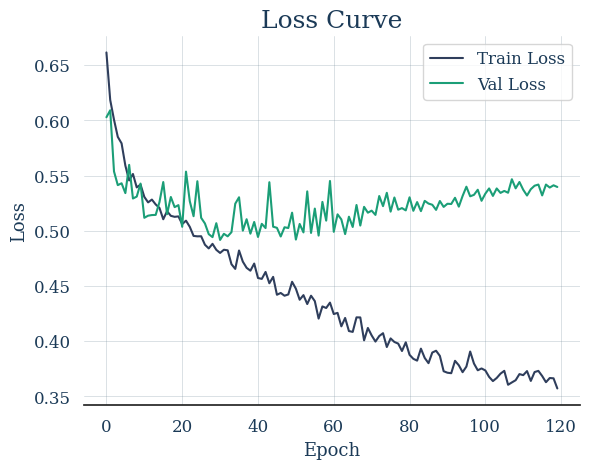

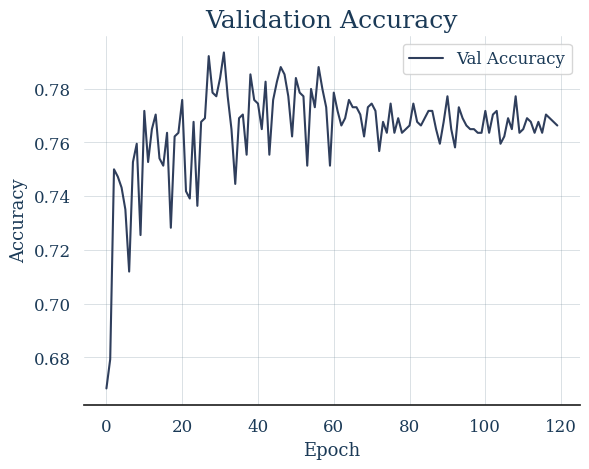

Final Accuracy: 0.7663043478260869
              precision    recall  f1-score   support

           0       0.76      0.77      0.77       368
           1       0.77      0.76      0.77       368

    accuracy                           0.77       736
   macro avg       0.77      0.77      0.77       736
weighted avg       0.77      0.77      0.77       736



In [522]:
history = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler=scheduler,
    epochs=120,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

plot_history(history)
final_evaluation(model, val_loader)

In [523]:
torch.save(model.state_dict(), "./output/eeg_bci_2b.pth")

# TRAINING PER SUBJECT 

In [524]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
BATCH_SIZE = 64
EPOCHS = 50

In [525]:
def final_evaluation(model, loader, device="cpu"):
    model = model.to(device)
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    acc = np.mean(np.array(preds) == np.array(labels))
    return acc, preds, labels

In [526]:
from tqdm import tqdm
import torch

def augment(x):
    # x: (B, T, C)
    
    # Gaussian noise
    x = x + 0.01 * torch.randn_like(x)
    
    # Time shift
    shift = torch.randint(-20, 20, (1,)).item()
    x = torch.roll(x, shifts=shift, dims=1)
    
    return x

def train(model, train_loader, val_loader, optimizer, criterion, scheduler=None, epochs=20, device="cpu"):
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    model.to(device)

    # total steps for tqdm = epochs * len(train_loader)
    pbar = tqdm(total=epochs * len(train_loader), desc="Training", leave=True)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = augment(X_batch)
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # update same progress bar
            pbar.update(1)
            pbar.set_postfix({
                "epoch": epoch + 1,
                "loss": f"{loss.item():.4f}"
            })

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # update tqdm postfix with validation info
        pbar.set_postfix({
            "epoch": epoch + 1,
            "train_loss": f"{avg_train_loss:.4f}",
            "val_acc": f"{val_acc:.4f}"
        })

    pbar.close()
    return history

===== Processing Subject 1/27 =====


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training: 100%|██████████| 100/100 [00:06<00:00, 15.92it/s, epoch=50, train_loss=0.3287, val_acc=0.7500]


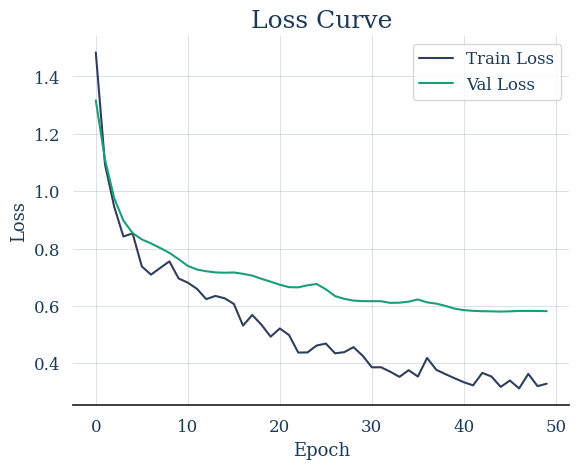

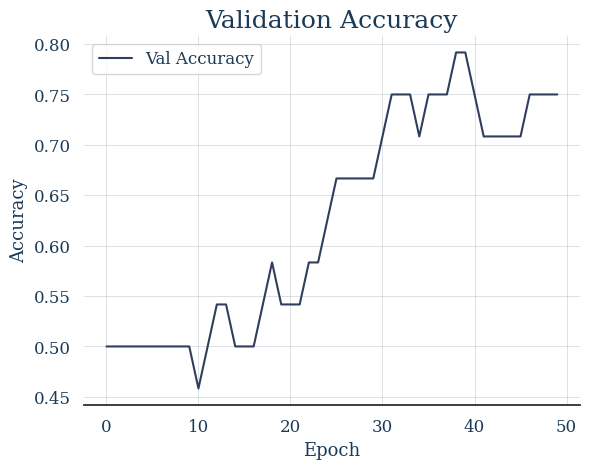

===== Processing Subject 2/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 16.42it/s, epoch=50, train_loss=0.6434, val_acc=0.5000]


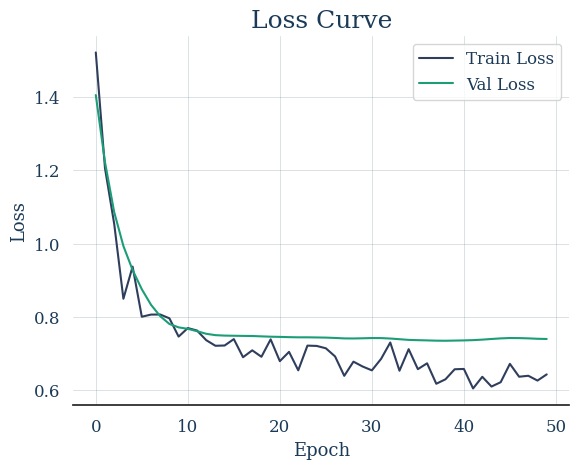

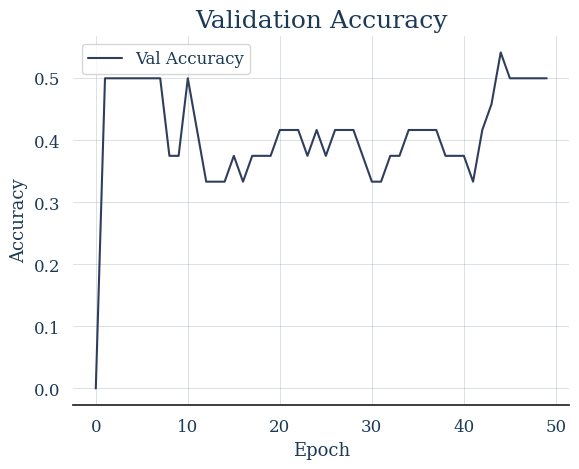

===== Processing Subject 3/27 =====


Training: 100%|██████████| 100/100 [00:08<00:00, 12.36it/s, epoch=50, train_loss=0.1109, val_acc=0.8750]


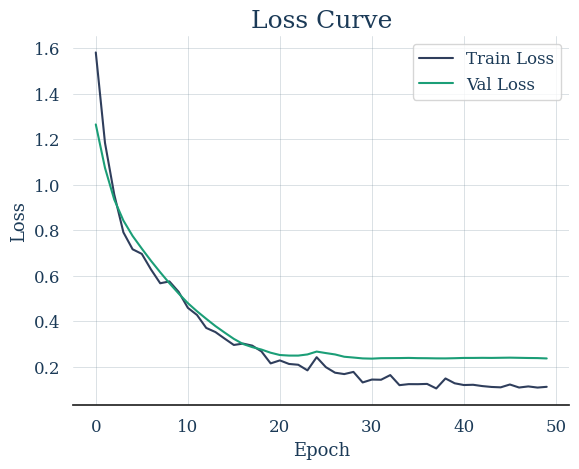

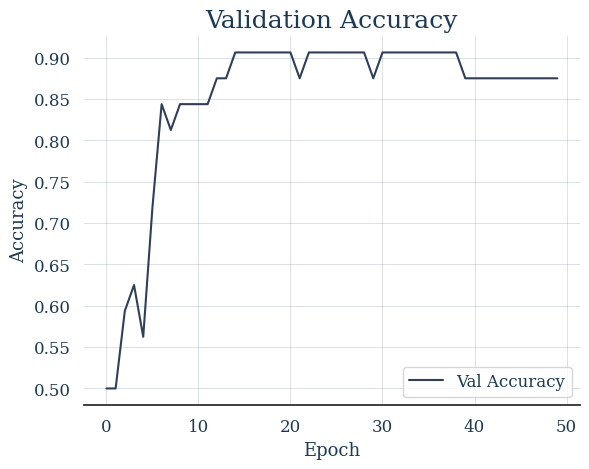

===== Processing Subject 4/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 16.13it/s, epoch=50, train_loss=0.6810, val_acc=0.5000]


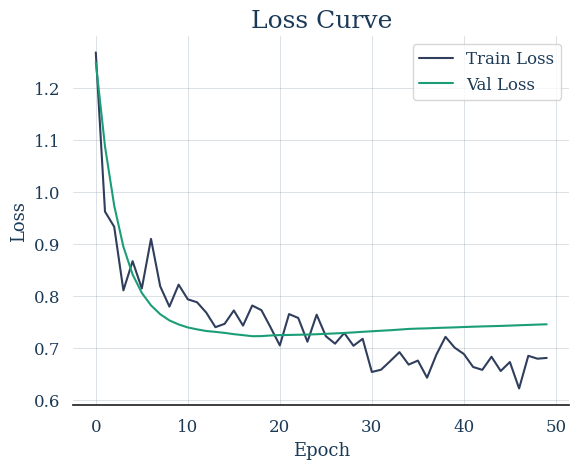

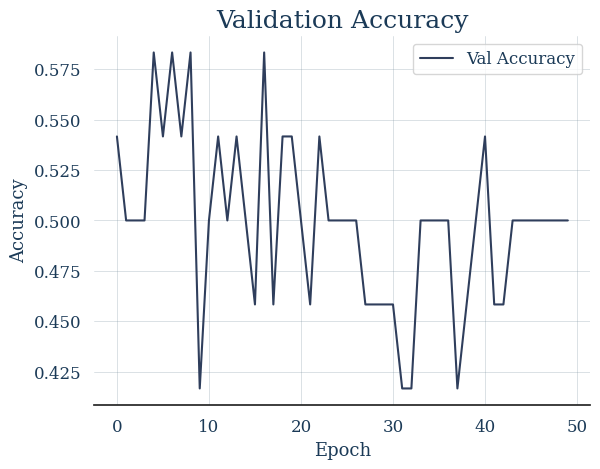

===== Processing Subject 5/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 16.29it/s, epoch=50, train_loss=0.5839, val_acc=0.6250]


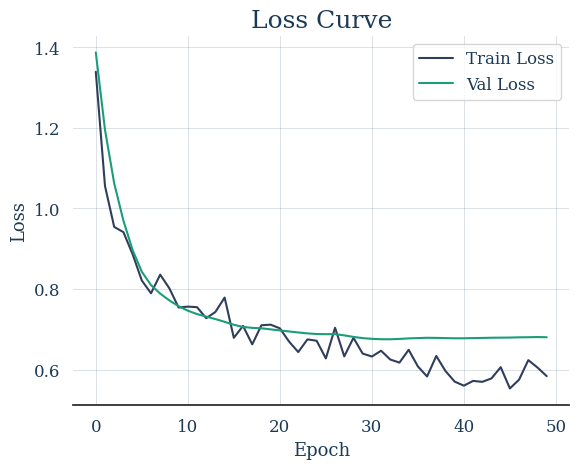

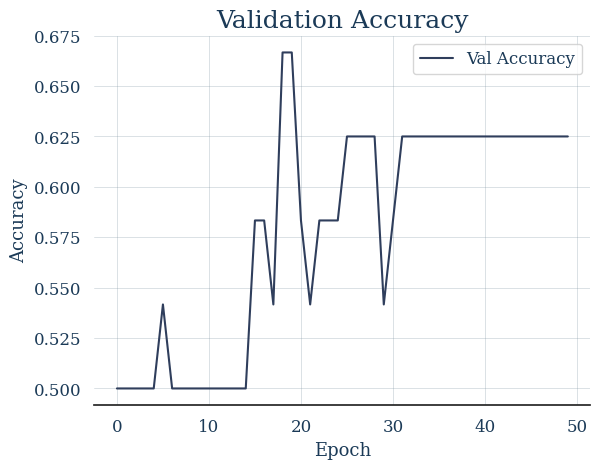

===== Processing Subject 6/27 =====


Training: 100%|██████████| 100/100 [00:08<00:00, 12.37it/s, epoch=50, train_loss=0.3797, val_acc=0.7812]


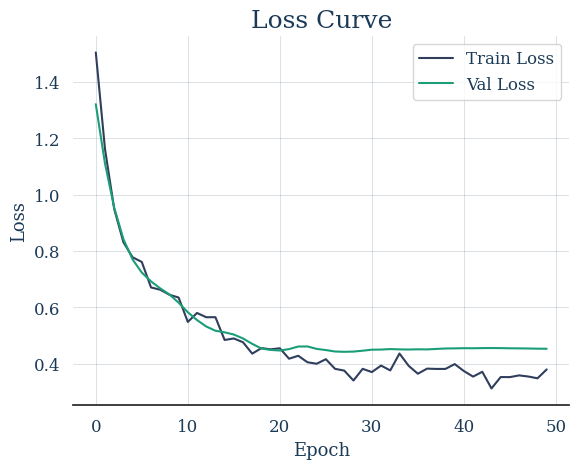

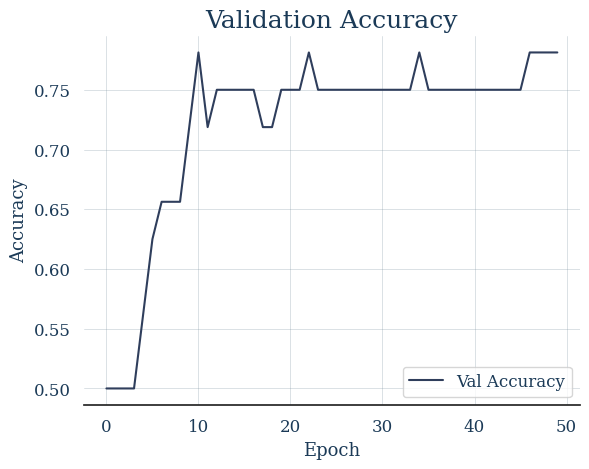

===== Processing Subject 7/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 16.22it/s, epoch=50, train_loss=0.6056, val_acc=0.5417]


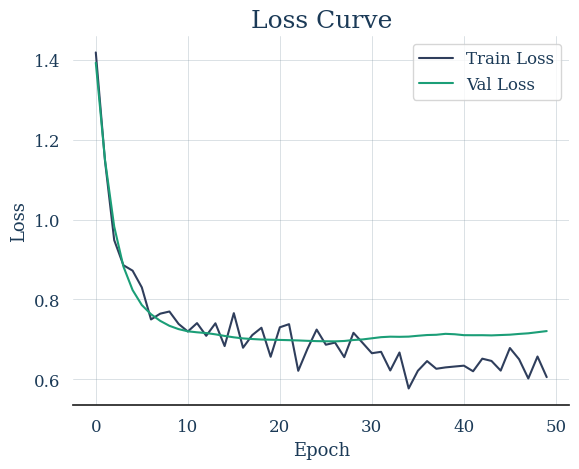

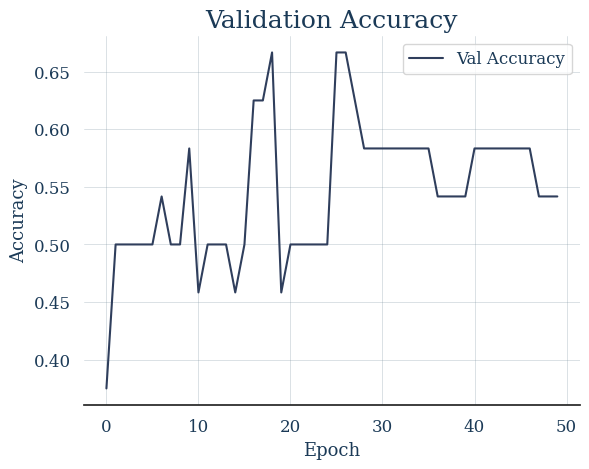

===== Processing Subject 8/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 16.27it/s, epoch=50, train_loss=0.6510, val_acc=0.6667]


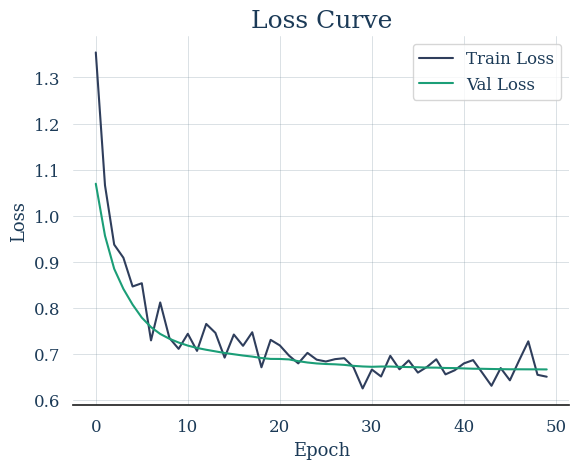

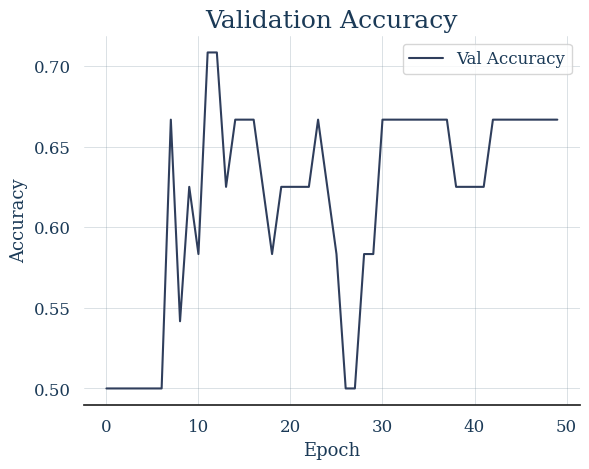

===== Processing Subject 9/27 =====


Training: 100%|██████████| 100/100 [00:08<00:00, 12.18it/s, epoch=50, train_loss=0.1054, val_acc=0.9375]


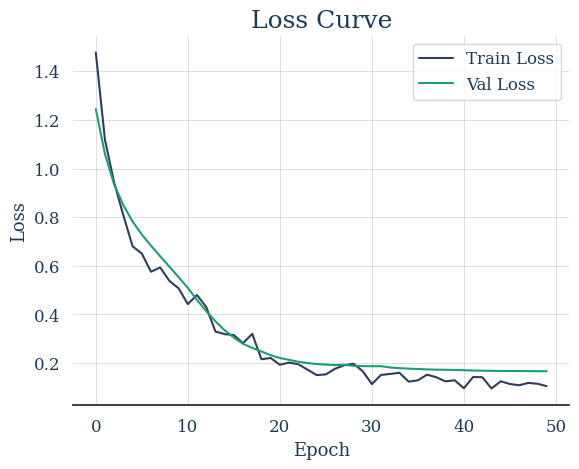

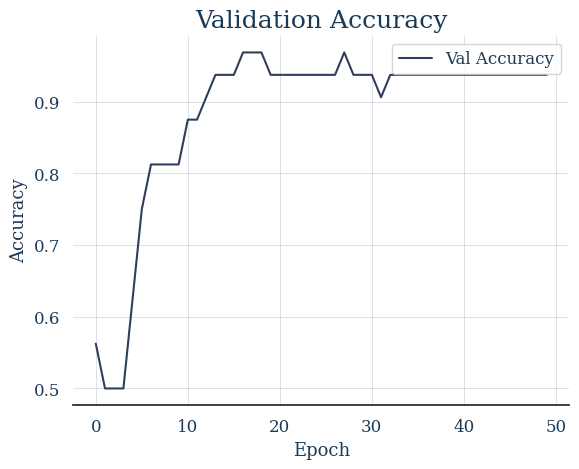

===== Processing Subject 10/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 15.88it/s, epoch=50, train_loss=0.4564, val_acc=0.7500]


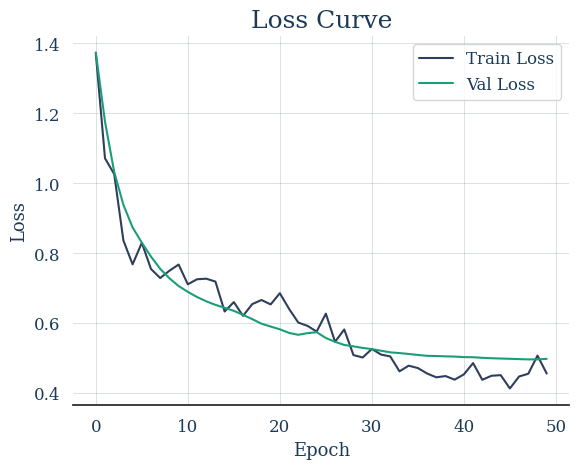

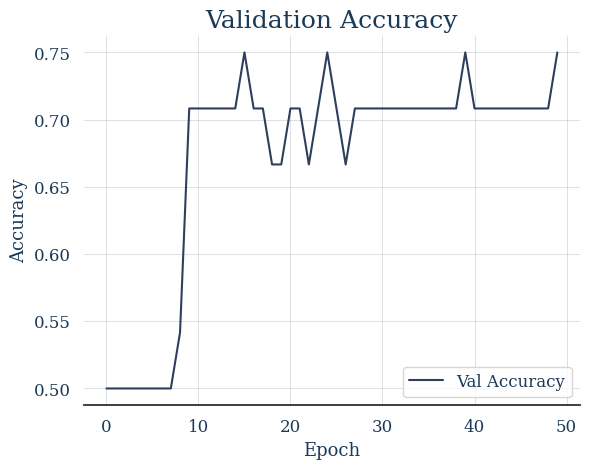

===== Processing Subject 11/27 =====


Training: 100%|██████████| 100/100 [00:07<00:00, 13.27it/s, epoch=50, train_loss=0.4032, val_acc=0.7857]


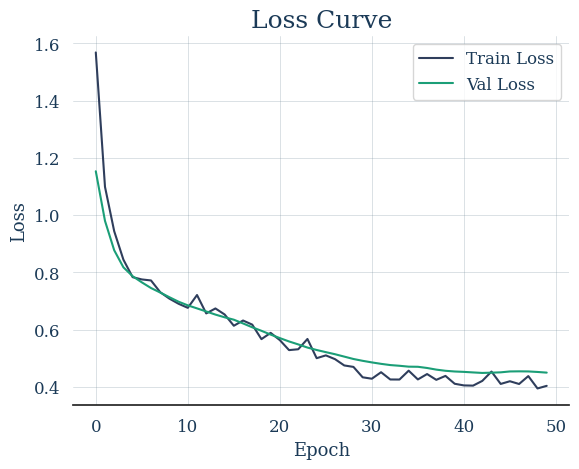

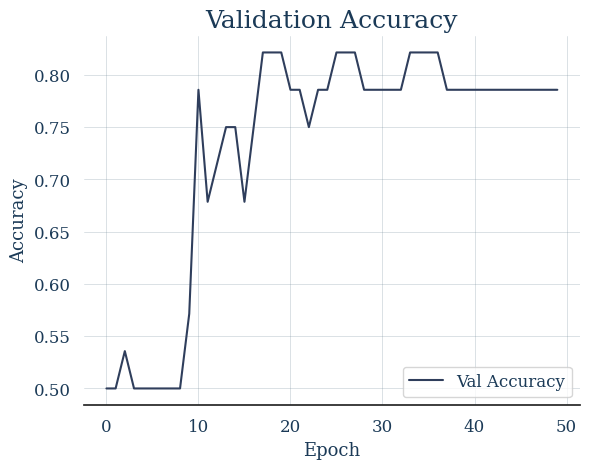

===== Processing Subject 12/27 =====


Training: 100%|██████████| 100/100 [00:08<00:00, 11.81it/s, epoch=50, train_loss=0.1307, val_acc=0.9375]


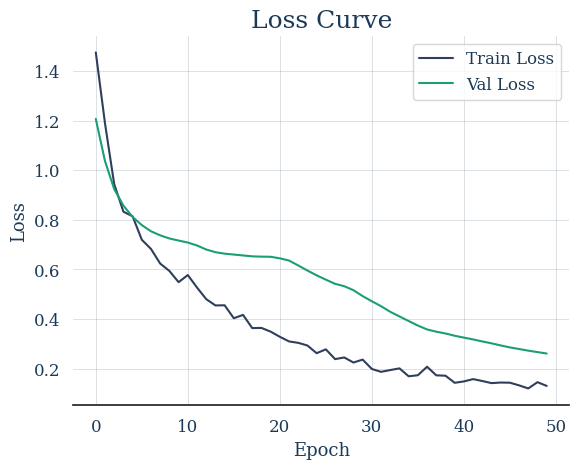

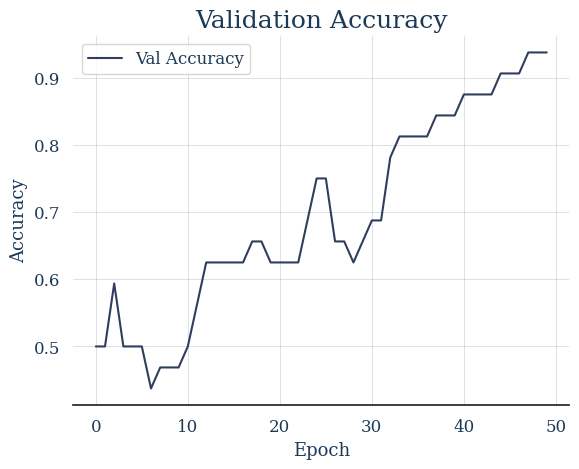

===== Processing Subject 13/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 15.33it/s, epoch=50, train_loss=0.4620, val_acc=0.7917]


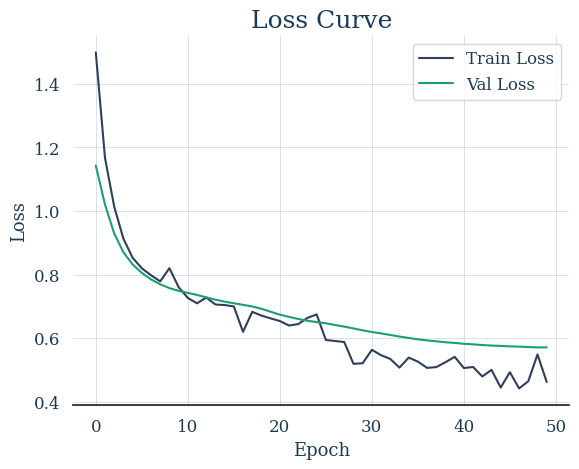

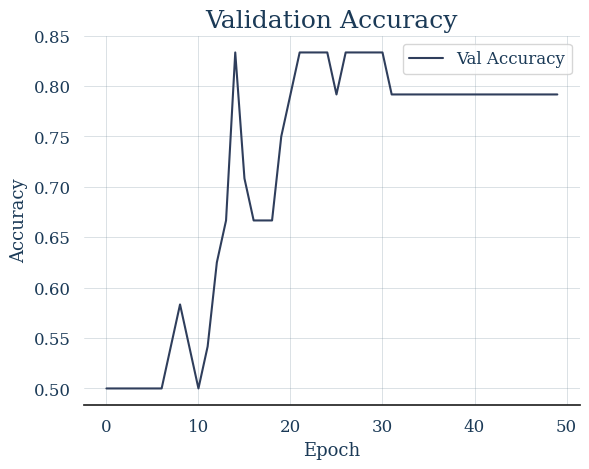

===== Processing Subject 14/27 =====


Training: 100%|██████████| 100/100 [00:07<00:00, 13.17it/s, epoch=50, train_loss=0.6668, val_acc=0.8214]


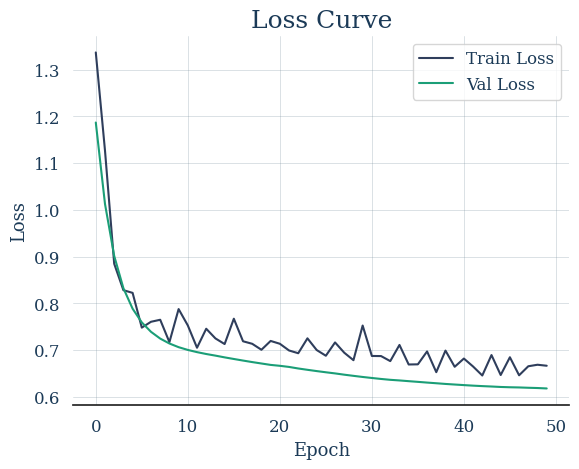

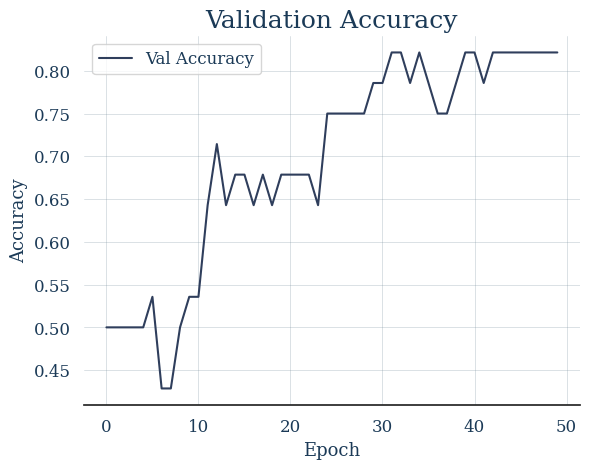

===== Processing Subject 15/27 =====


Training: 100%|██████████| 100/100 [00:08<00:00, 11.26it/s, epoch=50, train_loss=0.2372, val_acc=0.8750]


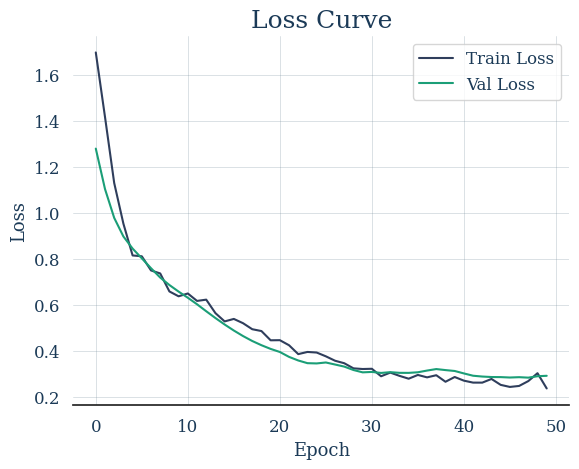

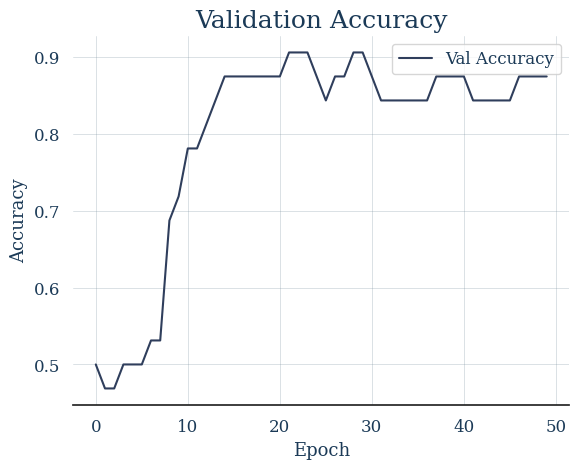

===== Processing Subject 16/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 14.84it/s, epoch=50, train_loss=0.4236, val_acc=0.9167]


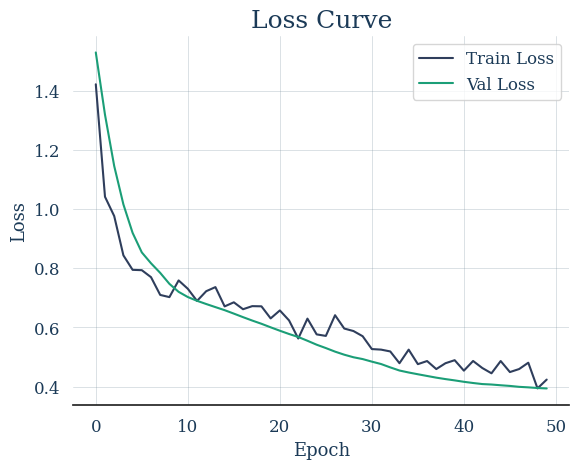

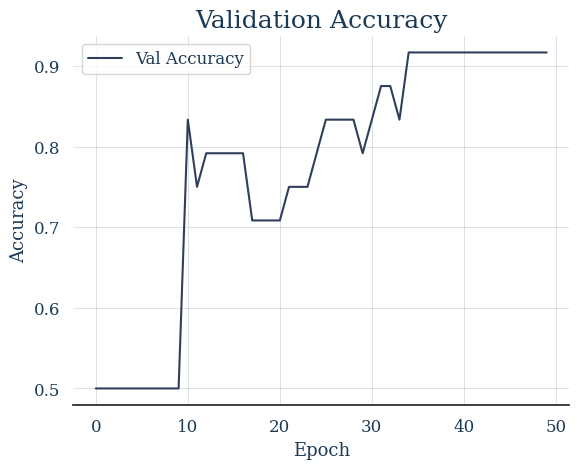

===== Processing Subject 17/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 15.11it/s, epoch=50, train_loss=0.5472, val_acc=0.5417]


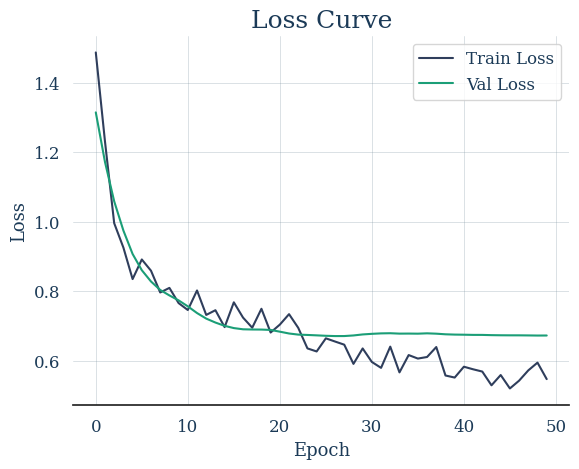

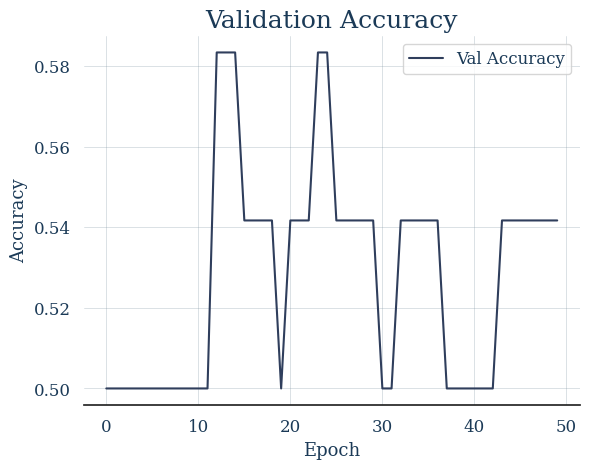

===== Processing Subject 18/27 =====


Training: 100%|██████████| 100/100 [00:08<00:00, 11.41it/s, epoch=50, train_loss=0.4503, val_acc=0.6875]


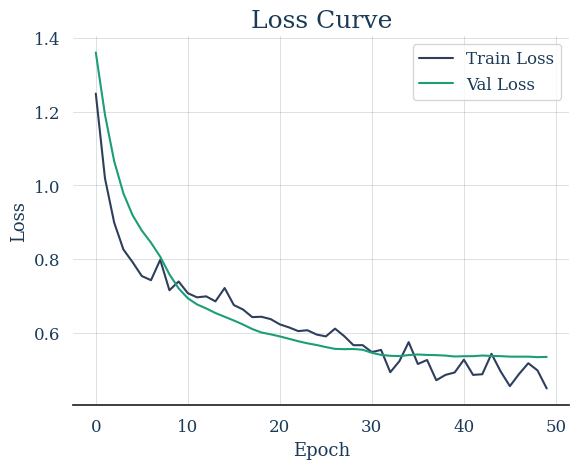

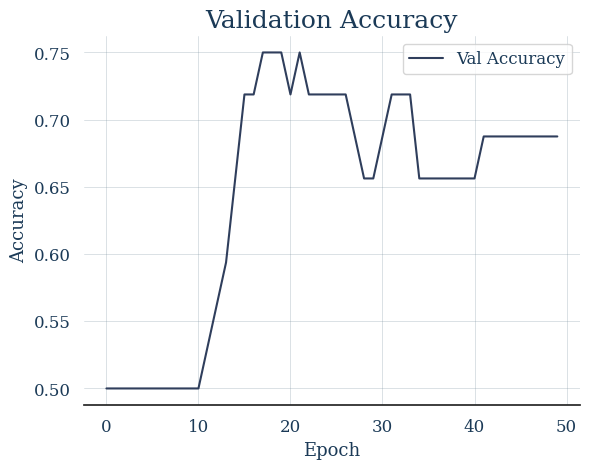

===== Processing Subject 19/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 15.66it/s, epoch=50, train_loss=0.4429, val_acc=0.4167]


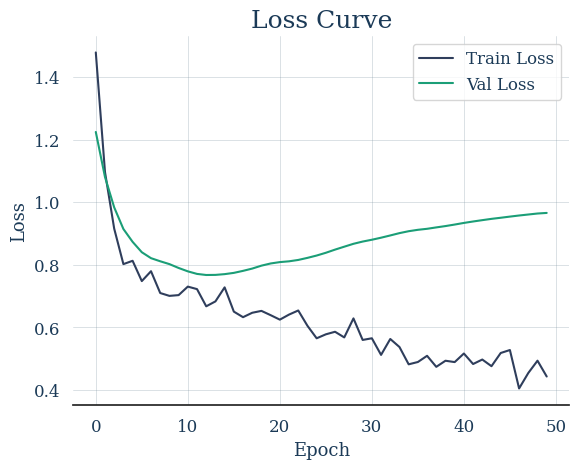

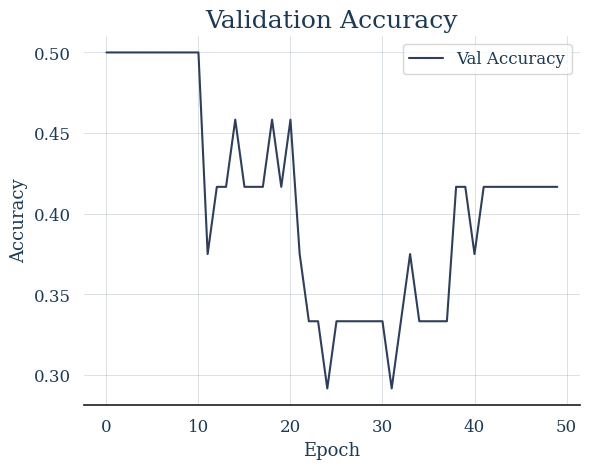

===== Processing Subject 20/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 15.56it/s, epoch=50, train_loss=0.5116, val_acc=0.5833]


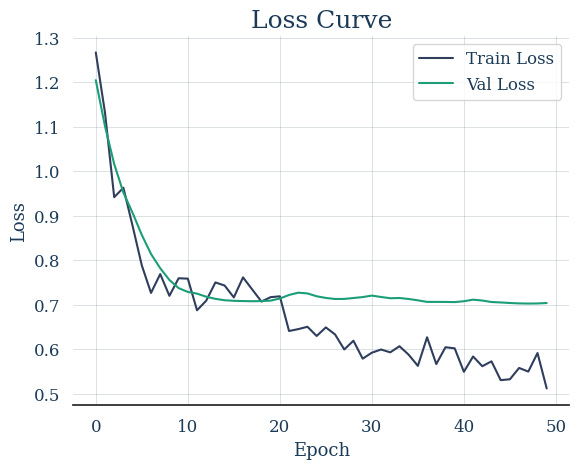

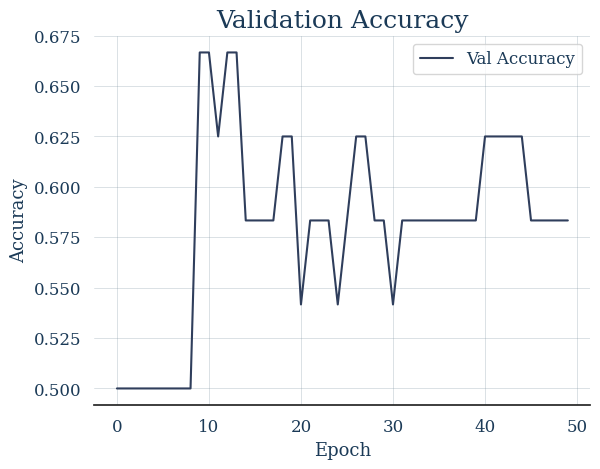

===== Processing Subject 21/27 =====


Training: 100%|██████████| 100/100 [00:08<00:00, 11.24it/s, epoch=50, train_loss=0.1440, val_acc=0.9375]


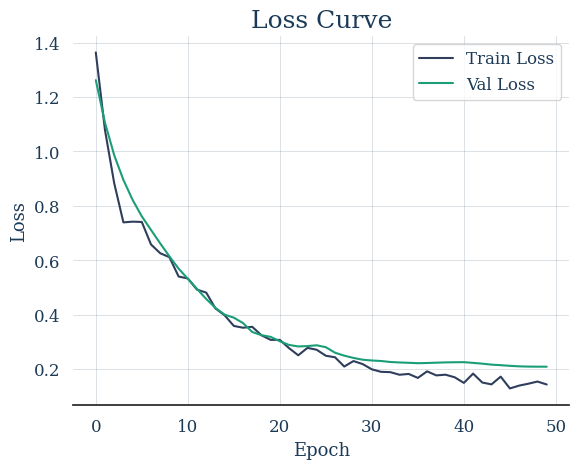

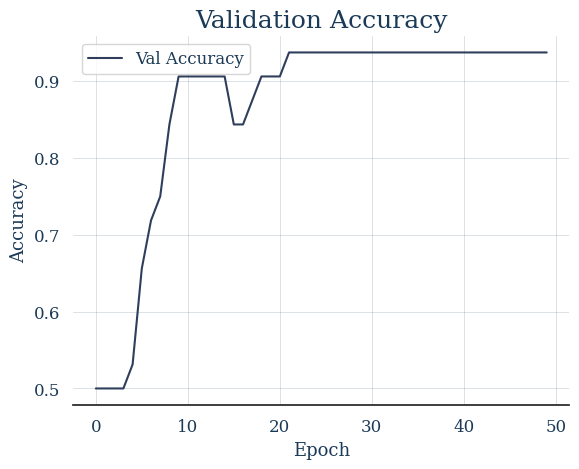

===== Processing Subject 22/27 =====


Training: 100%|██████████| 100/100 [00:08<00:00, 11.18it/s, epoch=50, train_loss=0.5611, val_acc=0.7188]


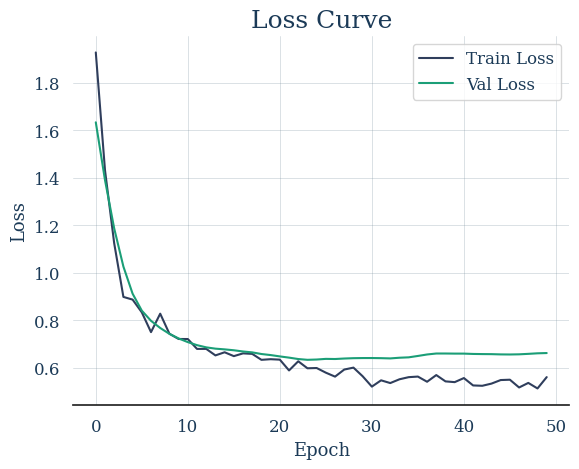

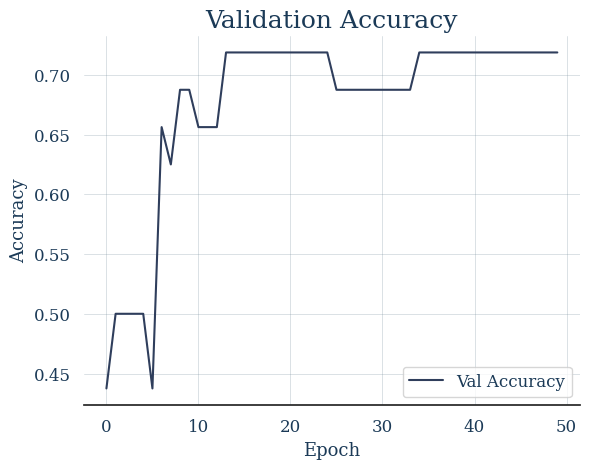

===== Processing Subject 23/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 14.68it/s, epoch=50, train_loss=0.4074, val_acc=0.7917]


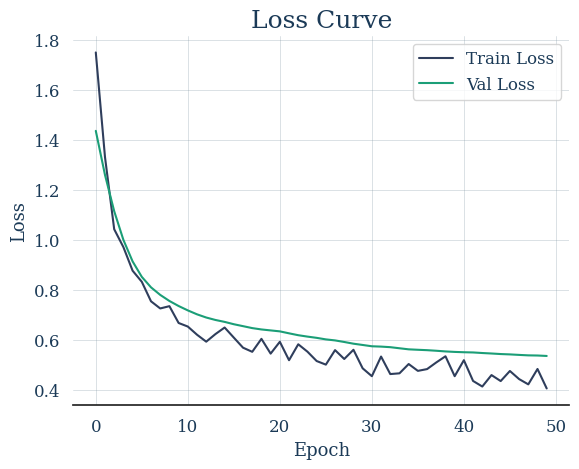

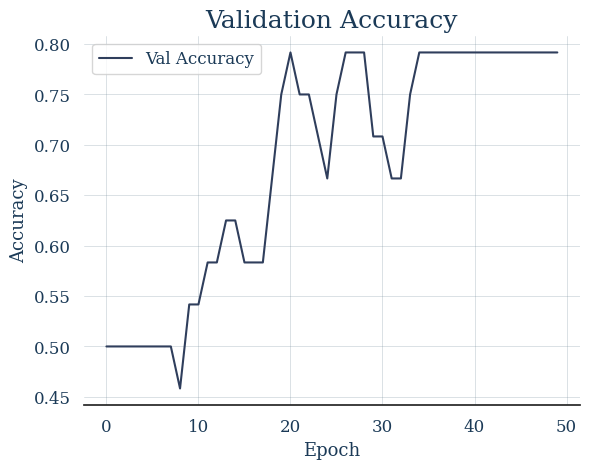

===== Processing Subject 24/27 =====


Training: 100%|██████████| 100/100 [00:09<00:00, 11.04it/s, epoch=50, train_loss=0.1867, val_acc=0.8750]


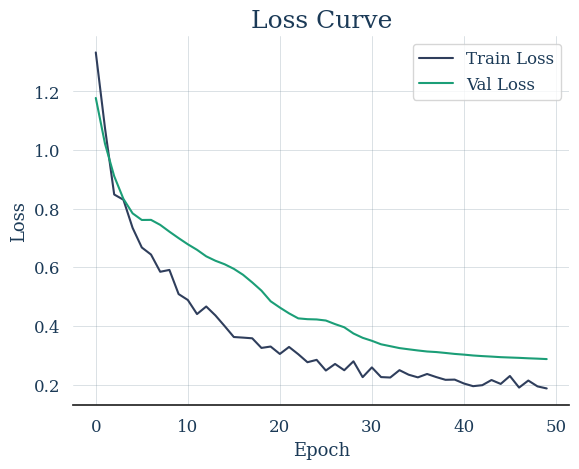

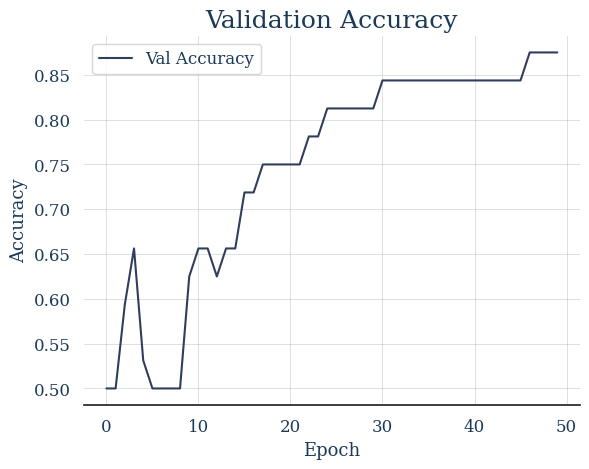

===== Processing Subject 25/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 14.93it/s, epoch=50, train_loss=0.6166, val_acc=0.6250]


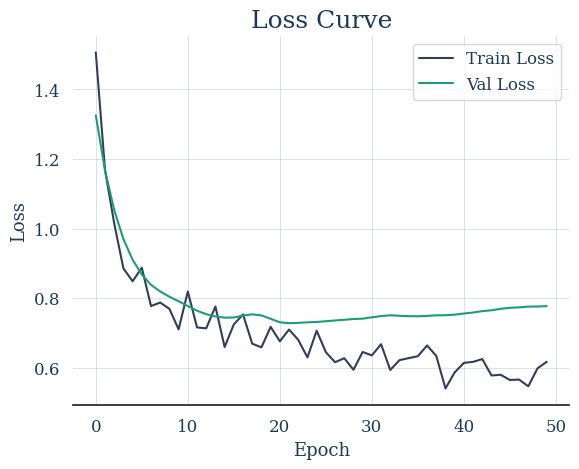

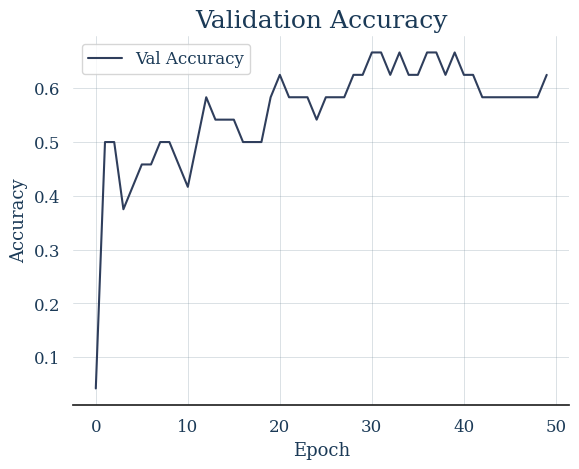

===== Processing Subject 26/27 =====


Training: 100%|██████████| 100/100 [00:06<00:00, 14.67it/s, epoch=50, train_loss=0.7167, val_acc=0.5000]


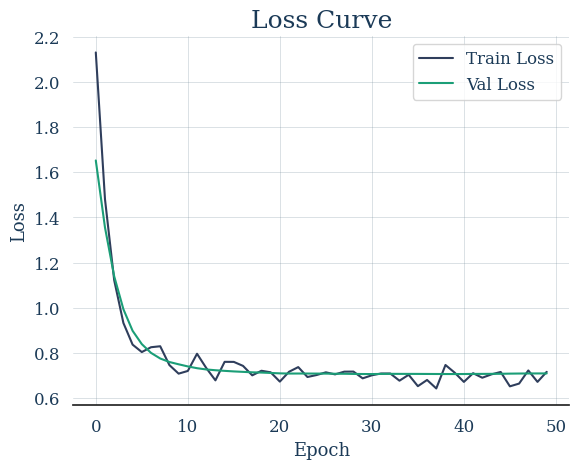

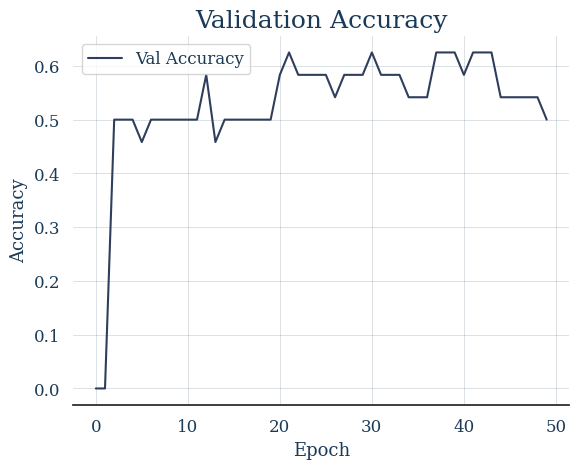

===== Processing Subject 27/27 =====


Training: 100%|██████████| 100/100 [00:09<00:00, 10.88it/s, epoch=50, train_loss=0.2307, val_acc=0.8750]


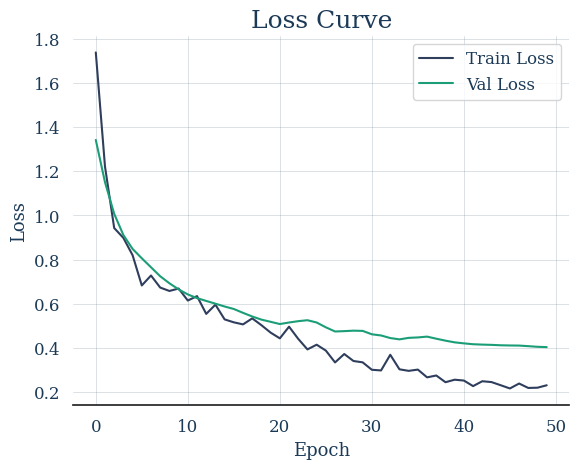

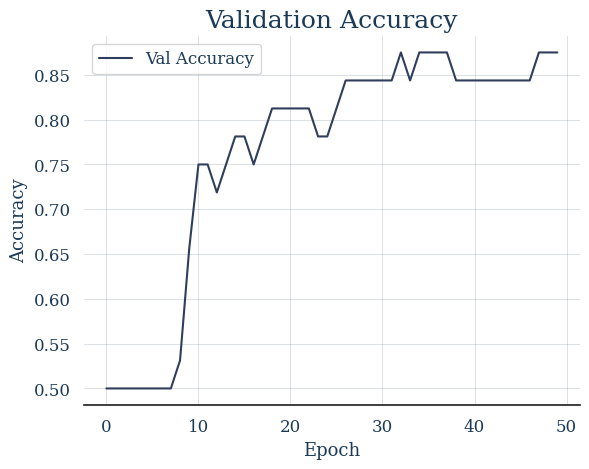

In [527]:
all_results = []
all_preds, all_labels = [], []
for subject_id, raw in enumerate(training_bci):
    print(f"===== Processing Subject {subject_id+1}/{len(training_bci)} =====")
    X_raw, y_raw = preprocess_raw(raw, event_id=BCI_Label_Mappings)

    X = np.array(X_raw)
    y = np.array(y_raw)

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    mean = X_train.mean(axis=(0,2), keepdims=True)
    std  = X_train.std(axis=(0,2), keepdims=True)

    X_train = (X_train - mean) / std
    X_val   = (X_val - mean) / std

    X_train = np.transpose(X_train, (0, 2, 1))  # (N, T, C)
    X_val   = np.transpose(X_val, (0, 2, 1))

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model2 = EEGModel(n_channels=X_train.shape[2], n_classes=4)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model2.parameters(), lr=1e-4)

    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    #     optimizer,
    #     mode='min',
    #     factor=0.5,
    #     patience=5
    # )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,     
        eta_min=1e-5 
    )

    history = train(
        model2,
        train_loader,
        val_loader,
        optimizer,
        criterion,        
        scheduler = scheduler,
        epochs=EPOCHS,
        device="cuda" if torch.cuda.is_available() else "cpu"
    )

    plot_history(history)
    val_acc, preds, labels = final_evaluation(model2, val_loader, device)

    all_preds.extend(preds)
    all_labels.extend(labels)

    all_results.append({
        "subject": subject_id,
        "val_accuracy": val_acc
    })


    

Subject 0 → Acc: 0.750
Subject 1 → Acc: 0.500
Subject 2 → Acc: 0.875
Subject 3 → Acc: 0.500
Subject 4 → Acc: 0.625
Subject 5 → Acc: 0.781
Subject 6 → Acc: 0.542
Subject 7 → Acc: 0.667
Subject 8 → Acc: 0.938
Subject 9 → Acc: 0.750
Subject 10 → Acc: 0.786
Subject 11 → Acc: 0.938
Subject 12 → Acc: 0.792
Subject 13 → Acc: 0.821
Subject 14 → Acc: 0.875
Subject 15 → Acc: 0.917
Subject 16 → Acc: 0.542
Subject 17 → Acc: 0.688
Subject 18 → Acc: 0.417
Subject 19 → Acc: 0.583
Subject 20 → Acc: 0.938
Subject 21 → Acc: 0.719
Subject 22 → Acc: 0.792
Subject 23 → Acc: 0.875
Subject 24 → Acc: 0.625
Subject 25 → Acc: 0.500
Subject 26 → Acc: 0.875


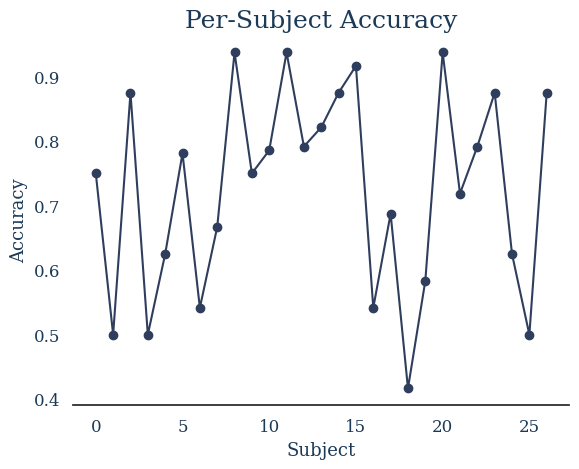

In [528]:
import pandas as pd
for r in all_results:
    print(f"Subject {r['subject']} → Acc: {r['val_accuracy']:.3f}")

df = pd.DataFrame(all_results)
df.to_csv("bci2a_results.csv", index=False)

import matplotlib.pyplot as plt

accs = [r["val_accuracy"] for r in all_results]

plt.plot(accs, marker='o')
plt.title("Per-Subject Accuracy")
plt.xlabel("Subject")
plt.ylabel("Accuracy")
plt.grid()
plt.show()